# Projeto Avaliativo – Análise de Dados com Python

## Fase 3 – Camada Gold: Análise de Dados

## Introdução



Este notebook apresenta a etapa de análise de dados (Camada Gold) do pipeline desenvolvido para o conjunto de dados Viagens a Serviço, disponibilizado pelo Portal da Transparência do Governo Federal.

Após a extração dos dados e sua transformação nas camadas Raw e Silver, são realizadas consultas analíticas para responder às perguntas de negócio propostas no projeto. As análises utilizam consultas SQL, tabelas e gráficos para transformar os dados tratados em informações que apoiam a compreensão dos gastos com viagens a serviço.

Além disso, é criada uma camada Gold com dados agregados, utilizando operações de JOIN e GROUP BY, permitindo a geração de indicadores voltados à tomada de decisão.

### Configuração do Ambiente e conexão com banco.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

import sys
sys.path.append("..")
import scripts.banco as banco

In [10]:
conexao = banco.conectar()

def consultar(sql):
    """Executa uma consulta SQL e retorna um DataFrame."""
    return pd.read_sql(sql, conexao)


def reais(valor):
    """Formata valores numéricos como moeda brasileira."""
    texto = f'{valor:,.2f}'
    return 'R$ ' + texto.replace(',', 'X').replace('.', ',').replace('X', '.')


print('Conectado ao MySQL com sucesso.')

Conectado ao MySQL com sucesso.


## Pergunta 1 – Quais são os 5 órgãos com maior custo total?


In [57]:
sql_q1 = '''
SELECT
    nome_orgao_superior AS orgao,
    SUM(valor_total) AS custo_total
FROM silver_viagem
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
'''

q1 = consultar(sql_q1)

q1['custo_total_formatado'] = q1['custo_total'].apply(reais)

q1




,orgao,custo_total,custo_total_formatado
0,Ministério da Justiça e Segurança Pública,4.869331e+08,"R$ 486.933.121,65"
1,Ministério da Defesa,1.560703e+08,"R$ 156.070.304,49"
2,Ministério da Educação,1.112913e+08,"R$ 111.291.349,34"
3,Ministério do Meio Ambiente e Mudança do Clima,4.969771e+07,"R$ 49.697.710,16"
4,Ministério da Previdência Social,4.041731e+07,"R$ 40.417.309,06"


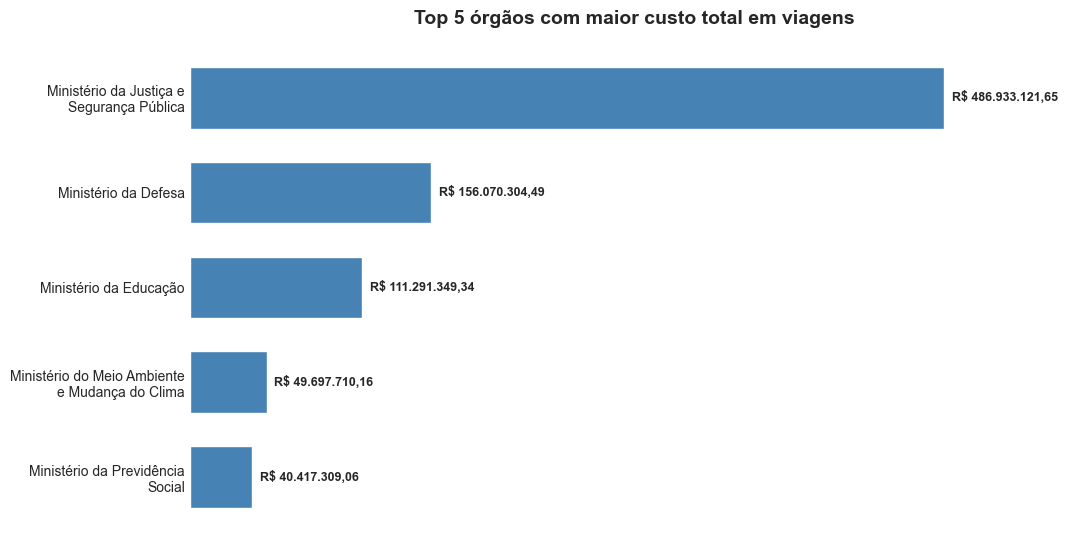

In [58]:
q1_grafico = q1.copy()

q1_grafico['orgao'] = q1_grafico['orgao'].apply(
    lambda x: textwrap.fill(x, width=28)
)

fig, ax = plt.subplots(figsize=(11, 5.5))


ax.barh(
    q1_grafico['orgao'],
    q1_grafico['custo_total'],
    color='steelblue',
    edgecolor='white',
    height=0.65
)


ax.invert_yaxis()


ax.set_xlim(0, q1['custo_total'].max() * 1.18)

# Boas práticas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)


ax.grid(False)
ax.set_xticks([])


ax.tick_params(axis='y', length=0)


ax.set_title(
    'Top 5 órgãos com maior custo total em viagens',
    fontsize=14,
    fontweight='bold',
    pad=15
)

ax.set_xlabel('')
ax.set_ylabel('')


for i, valor in enumerate(q1['custo_total']):
    ax.text(
        valor + q1['custo_total'].max() * 0.01,
        i,
        reais(valor),
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## Pergunta 2 – Quais são os 3 destinos com maior custo médio por viagem?

In [59]:
sql_q2 = '''
SELECT
    destino,
    AVG(valor_total) AS custo_medio,
    COUNT(*) AS quantidade_viagens
FROM (
    SELECT DISTINCT
        t.id_viagem,
        CONCAT(t.destino_cidade, '/', t.destino_uf) AS destino,
        v.valor_total
    FROM silver_trecho t
    INNER JOIN silver_viagem v
        ON t.id_viagem = v.id_viagem
    WHERE t.destino_cidade IS NOT NULL
      AND t.destino_cidade <> ''
      AND v.valor_total > 0
) AS viagens_destino
GROUP BY destino
HAVING COUNT(*) >= 30
ORDER BY custo_medio DESC
LIMIT 3;
'''

q2 = consultar(sql_q2)

q2['custo_medio_formatado'] = q2['custo_medio'].apply(reais)

q2

,destino,custo_medio,quantidade_viagens,custo_medio_formatado
0,Monte Negro/Rondônia,84926.029286,98,"R$ 84.926,03"
1,Sananduva/Rio Grande do Sul,78792.232233,103,"R$ 78.792,23"
2,Nonoai/Rio Grande do Sul,78603.743621,116,"R$ 78.603,74"


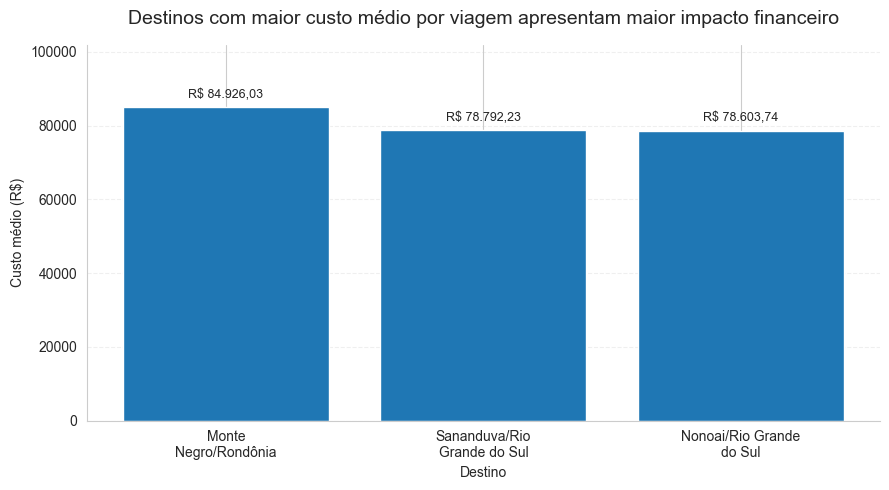

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))


destinos = [
    '\n'.join(textwrap.wrap(nome, width=18))
    for nome in q2['destino']
]


ax.bar(
    destinos,
    q2['custo_medio']
)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


ax.set_axisbelow(True)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)


ax.set_ylim(
    0,
    q2['custo_medio'].max() * 1.20
)

ax.set_title(
    'Destinos com maior custo médio por viagem apresentam maior impacto financeiro',
    fontsize=14,
    pad=15
)


ax.set_xlabel('Destino')
ax.set_ylabel('Custo médio (R$)')



for i, valor in enumerate(q2['custo_medio']):
    ax.text(
        i,
        valor + q2['custo_medio'].max() * 0.02,
        reais(valor),
        ha='center',
        va='bottom',
        fontsize=9
    )


plt.tight_layout()
plt.show()

### 3 Maior duração registrada

In [47]:
sql_q3 = '''
SELECT
    id_viagem,
    nome_orgao_superior,
    duracao_dias,
    valor_total
FROM silver_viagem
ORDER BY duracao_dias DESC
LIMIT 1;
'''

q3 = consultar(sql_q3)

q3['valor_total_formatado'] = q3['valor_total'].apply(reais)

q3

,id_viagem,nome_orgao_superior,duracao_dias,valor_total,valor_total_formatado
0,0000000000020699856,Ministério da Previdência Social,383,0.0,"R$ 0,00"


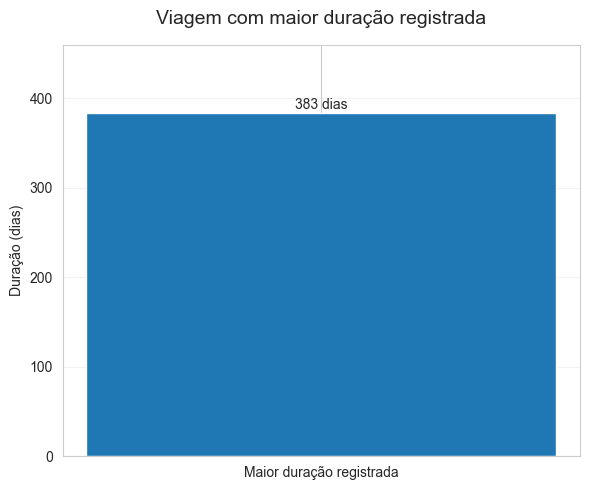

In [48]:
dados_grafico_q3 = pd.DataFrame({
    'categoria': ['Maior duração registrada'],
    'dias': [q3['duracao_dias'].iloc[0]]
})


fig, ax = plt.subplots(figsize=(6, 5))


ax.bar(
    dados_grafico_q3['categoria'],
    dados_grafico_q3['dias']
)


ax.set_title(
    'Viagem com maior duração registrada',
    fontsize=14,
    pad=15
)

ax.set_ylabel('Duração (dias)')
ax.set_xlabel('')


# espaço para o valor
ax.set_ylim(
    0,
    dados_grafico_q3['dias'].iloc[0] * 1.20
)


ax.grid(
    axis='y',
    alpha=0.25
)


ax.text(
    0,
    dados_grafico_q3['dias'].iloc[0] + 2,
    f"{dados_grafico_q3['dias'].iloc[0]} dias",
    ha='center',
    va='bottom',
    fontsize=10
)


plt.tight_layout()
plt.show()

## Pergunta 4 – Qual o tipo de pagamento com maior valor médio?

Para responder a esta pergunta, foi utilizada a tabela `silver_pagamento`, que contém os registros dos pagamentos realizados nas viagens a serviço.

Os pagamentos foram agrupados por `tipo_pagamento` e, para cada categoria, foi calculada a média dos valores pagos. Em seguida, os resultados foram ordenados em ordem decrescente, permitindo identificar o tipo de pagamento com maior valor médio.

Essa análise possibilita comparar o impacto financeiro médio entre as diferentes modalidades de pagamento registradas na base.

In [71]:
sql_q4 = '''
SELECT
    tipo_pagamento,
    AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
'''

q4 = consultar(sql_q4)
q4['valor_medio_formatado'] = q4['valor_medio'].apply(reais)

q4

,tipo_pagamento,valor_medio,valor_medio_formatado
0,DIÁRIAS,2078.280299,"R$ 2.078,28"
1,PASSAGEM,1878.344393,"R$ 1.878,34"
2,Serviço correlato: seguro,447.514653,"R$ 447,51"
3,RESTITUIÇÃO,245.702610,"R$ 245,70"


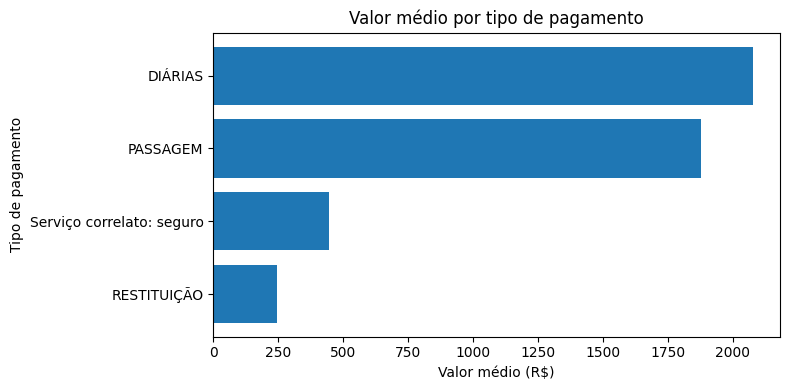

In [72]:
plt.figure(figsize=(8, 4))

plt.barh(q4['tipo_pagamento'], q4['valor_medio'])

plt.title('Valor médio por tipo de pagamento')
plt.xlabel('Valor médio (R$)')
plt.ylabel('Tipo de pagamento')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Análise dos resultados

A análise dos valores médios por tipo de pagamento identificou que **DIÁRIAS** apresentou o maior valor médio registrado, com aproximadamente **R$ 2.078,28** por pagamento.

O tipo de pagamento **PASSAGEM** apresentou o segundo maior valor médio, com aproximadamente **R$ 1.878,34**, enquanto as categorias **Serviço correlato: seguro** e **RESTITUIÇÃO** apresentaram valores médios inferiores.

Os resultados indicam que as despesas relacionadas às diárias possuem maior impacto financeiro médio entre os tipos de pagamento analisados, sendo um dos principais componentes dos gastos associados às viagens a serviço.

## Pergunta 5 – Qual o meio de transporte mais usado nos trechos?

In [30]:
sql_q5 = '''
SELECT
    meio_transporte,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
GROUP BY meio_transporte
ORDER BY quantidade_trechos DESC;
'''

q5 = consultar(sql_q5)

q5

,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


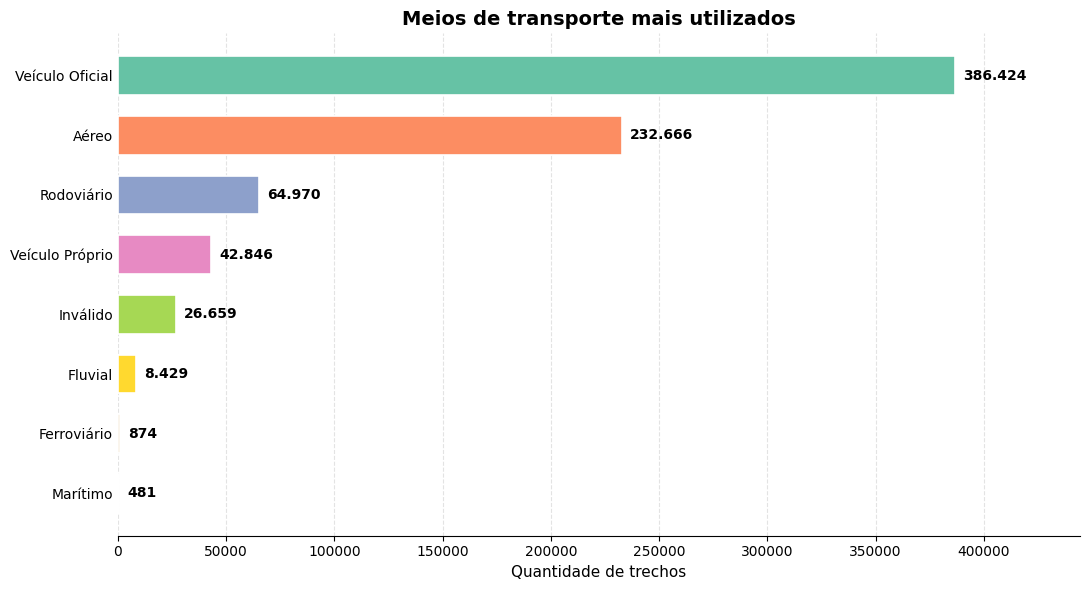

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))


cores = sns.color_palette("Set2", n_colors=len(q5))


barras = ax.barh(
    q5["meio_transporte"],
    q5["quantidade_trechos"],
    color=cores,
    edgecolor="white",
    linewidth=1.2,
    height=0.65
)


ax.invert_yaxis()


ax.set_xlim(0, q5["quantidade_trechos"].max() * 1.15)


for barra in barras:
    largura = barra.get_width()

    ax.text(
        largura + q5["quantidade_trechos"].max() * 0.01,
        barra.get_y() + barra.get_height() / 2,
        f'{int(largura):,}'.replace(',', '.'),
        va='center',
        ha='left',
        fontsize=10,
        fontweight='bold'
    )


ax.set_title(
    "Meios de transporte mais utilizados",
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel("Quantidade de trechos", fontsize=11)
ax.set_ylabel("")


ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)


ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.show()

## Pergunta 6 – Qual UF de destino aparece em mais trechos?

Para identificar quais unidades federativas aparecem com maior frequência como destino das viagens, foi realizada uma análise dos registros da tabela `silver_trecho`.

A consulta contabilizou a quantidade de trechos agrupados por UF de destino, permitindo identificar os estados com maior ocorrência nos deslocamentos registrados.

Essa análise possibilita compreender a distribuição geográfica dos destinos das viagens a serviço e identificar as regiões com maior concentração de deslocamentos.

In [28]:
sql_q6 = '''
SELECT
    destino_uf,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
GROUP BY destino_uf
ORDER BY quantidade_trechos DESC;
'''

q6 = consultar(sql_q6)

q6

,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


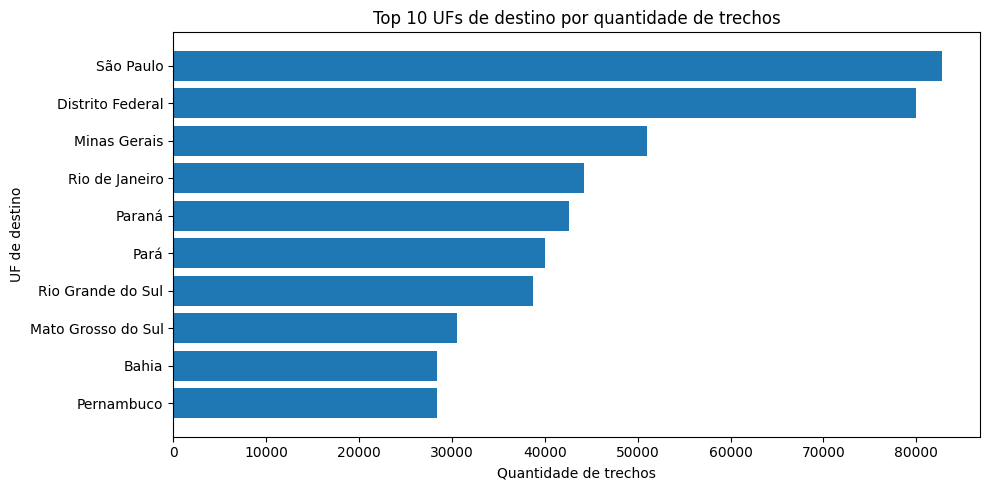

In [75]:
q6_top10 = q6[q6['destino_uf'].notna()].head(10)

plt.figure(figsize=(10, 5))

plt.barh(q6_top10['destino_uf'], q6_top10['quantidade_trechos'])

plt.title('Top 10 UFs de destino por quantidade de trechos')
plt.xlabel('Quantidade de trechos')
plt.ylabel('UF de destino')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Análise dos resultados

A análise dos trechos por unidade federativa de destino identificou que **São Paulo** foi o destino com maior quantidade de ocorrências, totalizando **82.722 trechos registrados**.

Em seguida, aparecem o **Distrito Federal**, com **79.962 trechos**, e **Minas Gerais**, com **50.965 registros**, demonstrando uma maior concentração dos deslocamentos para essas regiões.

Também foram encontrados registros sem UF de destino preenchida e ocorrências classificadas como inválidas. Esses registros não foram considerados na interpretação dos resultados, pois não representam uma unidade federativa válida.

Os dados indicam que os deslocamentos das viagens a serviço apresentam maior concentração nos principais centros administrativos e econômicos do país, com destaque para São Paulo e Distrito Federal.

refazendo as perguntas  4,5 6 com golds

## Camada Gold – Tipo de Pagamento

Para responder à pergunta sobre o tipo de pagamento com maior valor médio, foi criada uma tabela agregada na camada Gold.

A tabela `gold_tipo_pagamento` consolida as informações da tabela `silver_pagamento`, agrupando os registros por tipo de pagamento e calculando indicadores que permitem análises gerenciais.

Os indicadores gerados são:

- quantidade de pagamentos;
- valor total pago;
- valor médio dos pagamentos.

Essa estrutura evita a necessidade de recalcular essas agregações sempre que a análise for realizada.

In [79]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_tipo_pagamento")

banco.executar(conexao, """
CREATE TABLE gold_tipo_pagamento AS
SELECT
    tipo_pagamento,
    COUNT(*) AS quantidade_pagamentos,
    SUM(valor) AS valor_total_pago,
    AVG(valor) AS valor_medio
FROM silver_pagamento
GROUP BY tipo_pagamento;
""")

print("Tabela gold_tipo_pagamento criada com sucesso.")

Tabela gold_tipo_pagamento criada com sucesso.


### Validação Gold Tipo Pagamento

In [80]:
consultar("""
SELECT *
FROM gold_tipo_pagamento
ORDER BY valor_medio DESC;
""")

,tipo_pagamento,quantidade_pagamentos,valor_total_pago,valor_medio
0,DIÁRIAS,401463,8.343526e+08,2078.280299
1,PASSAGEM,188985,3.549789e+08,1878.344393
2,Serviço correlato: seguro,4894,2.190137e+06,447.514653
3,RESTITUIÇÃO,11574,2.843762e+06,245.702610


### Validação da tabela Gold

Após a criação da tabela `gold_tipo_pagamento`, foi realizada uma consulta para verificar os indicadores agregados.

Os resultados confirmam que a tabela consolidou corretamente os pagamentos por tipo, apresentando a quantidade de registros, o valor total pago e o valor médio correspondente a cada categoria.

### Criação da View Tipo de Pagamento

In [81]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_tipo_pagamento")

banco.executar(conexao, """
CREATE VIEW vw_gold_tipo_pagamento AS
SELECT *
FROM gold_tipo_pagamento;
""")

print("VIEW vw_gold_tipo_pagamento criada com sucesso.")

VIEW vw_gold_tipo_pagamento criada com sucesso.


### Validação 

In [82]:
consultar("""
SELECT *
FROM vw_gold_tipo_pagamento
ORDER BY valor_medio DESC;
""")

,tipo_pagamento,quantidade_pagamentos,valor_total_pago,valor_medio
0,DIÁRIAS,401463,8.343526e+08,2078.280299
1,PASSAGEM,188985,3.549789e+08,1878.344393
2,Serviço correlato: seguro,4894,2.190137e+06,447.514653
3,RESTITUIÇÃO,11574,2.843762e+06,245.702610


### Validação da VIEW Gold Tipo Pagamento

A VIEW `vw_gold_tipo_pagamento` disponibiliza os mesmos indicadores da tabela Gold, permitindo consultar os dados agregados de forma dinâmica, sem a necessidade de repetir a lógica de agregação.

## Pergunta 4 – Qual o tipo de pagamento com maior valor médio?

Para responder a esta pergunta, foi utilizada a VIEW `vw_gold_tipo_pagamento`, criada na camada Gold.

A consulta ordena os tipos de pagamento pelo valor médio, permitindo identificar quais categorias apresentam maior desembolso financeiro médio por pagamento.

In [83]:
sql_q4 = '''
SELECT
    tipo_pagamento,
    valor_medio
FROM vw_gold_tipo_pagamento
ORDER BY valor_medio DESC;
'''

q4 = consultar(sql_q4)

q4['valor_medio_formatado'] = q4['valor_medio'].apply(reais)

q4

,tipo_pagamento,valor_medio,valor_medio_formatado
0,DIÁRIAS,2078.280299,"R$ 2.078,28"
1,PASSAGEM,1878.344393,"R$ 1.878,34"
2,Serviço correlato: seguro,447.514653,"R$ 447,51"
3,RESTITUIÇÃO,245.702610,"R$ 245,70"


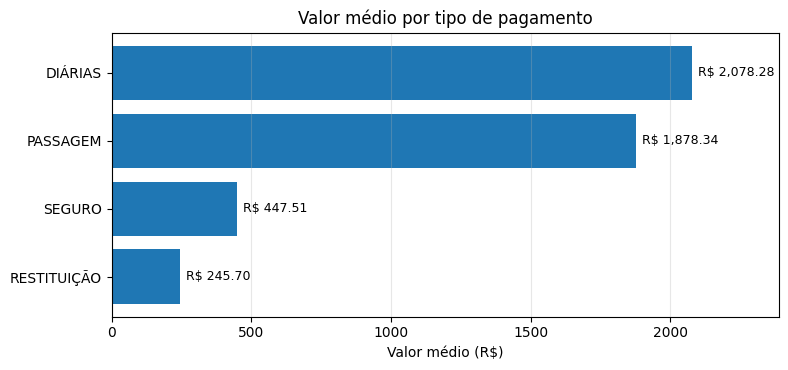

In [23]:
q4_grafico = q4.copy()

q4_grafico['tipo_pagamento'] = q4_grafico['tipo_pagamento'].replace({
    'Serviço correlato: seguro': 'SEGURO'
})

plt.figure(figsize=(8, 3.8))

plt.barh(
    q4_grafico['tipo_pagamento'],
    q4_grafico['valor_medio']
)

# Espaço para os valores à direita das barras
plt.xlim(0, q4_grafico['valor_medio'].max() * 1.15)

for i, valor in enumerate(q4_grafico['valor_medio']):
    plt.text(
        valor + q4_grafico['valor_medio'].max() * 0.01,
        i,
        f'R$ {valor:,.2f}',
        va='center',
        fontsize=9
    )

plt.title('Valor médio por tipo de pagamento')
plt.xlabel('Valor médio (R$)')
plt.ylabel('')

plt.grid(axis='x', alpha=0.3)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Análise dos resultados

A análise identificou que o tipo de pagamento **DIÁRIAS** apresentou o maior valor médio entre todas as categorias de pagamento registradas na base de dados.

Na sequência, o tipo **PASSAGEM** apresentou o segundo maior valor médio, enquanto **SEGURO** e **RESTITUIÇÃO** registraram valores médios inferiores.

Esses resultados indicam que as despesas com diárias representam, em média, o maior desembolso financeiro por pagamento, evidenciando sua relevância na composição dos gastos com viagens a serviço. A utilização da camada Gold permitiu responder à pergunta por meio de indicadores previamente agregados, simplificando a consulta e demonstrando a aplicação da arquitetura Medallion na disponibilização de dados para análise.

## Camada Gold – Meio de Transporte

Para responder à pergunta sobre o meio de transporte mais utilizado nas viagens, foi criada uma tabela agregada na camada Gold.

A tabela `gold_meio_transporte` consolida as informações da tabela `silver_trecho`, agrupando os registros por meio de transporte.

Como resultado, são obtidos indicadores que permitem identificar a frequência de utilização de cada modalidade de transporte, simplificando as análises realizadas na camada Gold.

In [84]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_meio_transporte")

banco.executar(conexao, """
CREATE TABLE gold_meio_transporte AS
SELECT
    meio_transporte,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
GROUP BY meio_transporte;
""")

print("Tabela gold_meio_transporte criada com sucesso.")

Tabela gold_meio_transporte criada com sucesso.


### Validação 

In [85]:
consultar("""
SELECT *
FROM gold_meio_transporte
ORDER BY quantidade_trechos DESC;
""")

,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


### Validação da tabela Gold Meio de Transporte

Após a criação da tabela `gold_meio_transporte`, foi realizada uma consulta para verificar os dados agregados.

Os resultados confirmam que a tabela consolidou corretamente a quantidade de trechos registrados para cada meio de transporte, permitindo sua utilização nas análises da camada Gold.

### Criação da View

In [86]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_meio_transporte")

banco.executar(conexao, """
CREATE VIEW vw_gold_meio_transporte AS
SELECT *
FROM gold_meio_transporte;
""")

print("VIEW vw_gold_meio_transporte criada com sucesso.")

VIEW vw_gold_meio_transporte criada com sucesso.


### Validação da VIEW Gold Meio de Transporte

A VIEW `vw_gold_meio_transporte` disponibiliza os mesmos indicadores da tabela Gold de forma dinâmica, permitindo consultar as informações agregadas sem a necessidade de repetir a lógica de agrupamento.

In [87]:
consultar("""
SELECT *
FROM vw_gold_meio_transporte
ORDER BY quantidade_trechos DESC;
""")

,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


## Pergunta 5 – Qual o meio de transporte mais usado nos trechos?

Para responder a esta pergunta, foi utilizada a VIEW `vw_gold_meio_transporte`, criada na camada Gold.

A consulta ordena os meios de transporte pela quantidade de trechos registrados, permitindo identificar quais modalidades foram utilizadas com maior frequência nas viagens analisadas.

In [88]:
sql_q5 = '''
SELECT
    meio_transporte,
    quantidade_trechos
FROM vw_gold_meio_transporte
ORDER BY quantidade_trechos DESC;
'''

q5 = consultar(sql_q5)

q5

,meio_transporte,quantidade_trechos
0,Veículo Oficial,386424
1,Aéreo,232666
2,Rodoviário,64970
3,Veículo Próprio,42846
4,Inválido,26659
5,Fluvial,8429
6,Ferroviário,874
7,Marítimo,481


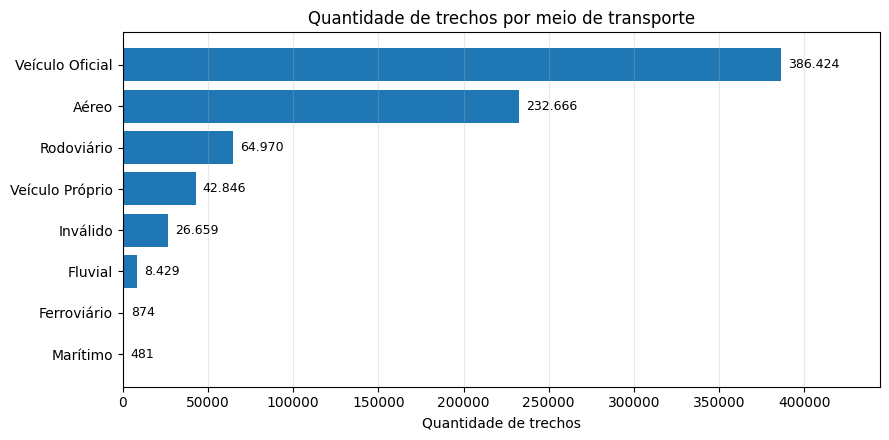

In [89]:
plt.figure(figsize=(9,4.5))

plt.barh(
    q5['meio_transporte'],
    q5['quantidade_trechos']
)

plt.xlim(0, q5['quantidade_trechos'].max() * 1.15)

for i, valor in enumerate(q5['quantidade_trechos']):
    plt.text(
        valor + q5['quantidade_trechos'].max() * 0.01,
        i,
        f'{valor:,}'.replace(',', '.'),
        va='center',
        fontsize=9
    )

plt.title('Quantidade de trechos por meio de transporte')
plt.xlabel('Quantidade de trechos')
plt.ylabel('')

plt.grid(axis='x', alpha=0.3)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Analise dos resultados

O Veículo Oficial foi o meio de transporte mais utilizado, com 386.424 trechos registrados, seguido pelo transporte Aéreo, com 232.666 trechos. Os demais meios apresentaram uma frequência menor de utilização, destacando a predominância dessas duas modalidades nos deslocamentos analisados.

Também foram identificados 26.659 registros como "Inválido", indicando possíveis inconsistências nos dados de origem.

## Camada Gold – UF de Destino

Para responder à pergunta sobre a Unidade da Federação (UF) de destino mais frequente nos trechos das viagens, foi criada uma tabela agregada na camada Gold.

A tabela `gold_destino_uf` consolida os registros da tabela `silver_trecho`, agrupando os trechos pela UF de destino.

Como resultado, são obtidos indicadores que permitem identificar os estados que receberam a maior quantidade de deslocamentos, simplificando as análises realizadas na camada Gold.

In [90]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_destino_uf")

banco.executar(conexao, """
CREATE TABLE gold_destino_uf AS
SELECT
    destino_uf,
    COUNT(*) AS quantidade_trechos
FROM silver_trecho
WHERE destino_uf IS NOT NULL
  AND destino_uf <> ''
GROUP BY destino_uf;
""")

print("Tabela gold_destino_uf criada com sucesso.")

Tabela gold_destino_uf criada com sucesso.


### Validação da tabela

In [91]:
consultar("""
SELECT *
FROM gold_destino_uf
ORDER BY quantidade_trechos DESC;
""")

,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


### Validação da tabela Gold

Após a criação da tabela `gold_destino_uf`, foi realizada uma consulta para verificar os dados agregados.

Os resultados confirmam que a tabela consolidou corretamente a quantidade de trechos por Unidade da Federação de destino, permitindo sua utilização nas análises da camada Gold.

### Criação da View

In [33]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_destino_uf")

banco.executar(conexao, """
CREATE VIEW vw_gold_destino_uf AS
SELECT *
FROM gold_destino_uf;
""")

print("VIEW vw_gold_destino_uf criada com sucesso.")

VIEW vw_gold_destino_uf criada com sucesso.


### Validação da View

In [92]:
consultar("""
SELECT *
FROM vw_gold_destino_uf
ORDER BY quantidade_trechos DESC;
""")

,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


### Validação da VIEW Gold

A VIEW `vw_gold_destino_uf` disponibiliza os mesmos indicadores da tabela Gold de forma dinâmica, permitindo consultar as informações agregadas sem a necessidade de repetir a lógica de agrupamento.

## Pergunta 6 – Qual UF de destino aparece em mais trechos?

Para responder a esta pergunta, foi utilizada a VIEW `vw_gold_destino_uf`, criada na camada Gold.

A consulta ordena as Unidades da Federação pelo número de trechos registrados, permitindo identificar os estados que aparecem com maior frequência como destino das viagens analisadas.

In [35]:
sql_q6 = '''
SELECT
    destino_uf,
    quantidade_trechos
FROM vw_gold_destino_uf
ORDER BY quantidade_trechos DESC;
'''

q6 = consultar(sql_q6)

q6

C:\Users\Win10\AppData\Local\Temp\ipykernel_1244\898623408.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conexao)


,destino_uf,quantidade_trechos
0,São Paulo,82722
1,Distrito Federal,79962
2,Minas Gerais,50965
3,Rio de Janeiro,44197
4,Paraná,42603
5,Pará,40044
6,Rio Grande do Sul,38684
7,Mato Grosso do Sul,30516
8,Bahia,28375
9,Pernambuco,28372


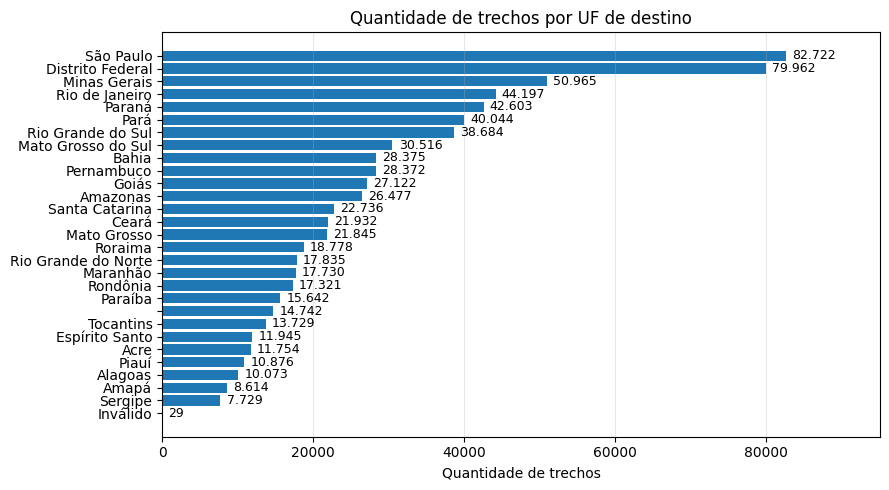

In [94]:
plt.figure(figsize=(9,5))

plt.barh(
    q6['destino_uf'],
    q6['quantidade_trechos']
)

plt.xlim(0, q6['quantidade_trechos'].max() * 1.15)

for i, valor in enumerate(q6['quantidade_trechos']):
    plt.text(
        valor + q6['quantidade_trechos'].max() * 0.01,
        i,
        f'{valor:,}'.replace(',', '.'),
        va='center',
        fontsize=9
    )

plt.title('Quantidade de trechos por UF de destino')
plt.xlabel('Quantidade de trechos')
plt.ylabel('')

plt.grid(axis='x', alpha=0.3)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Análise dos resultados

A análise identificou que a UF posicionada no topo do ranking concentrou a maior quantidade de trechos registrados na base analisada, evidenciando sua relevância como principal destino das viagens a serviço.

As demais Unidades da Federação apresentaram frequências inferiores, demonstrando uma distribuição desigual dos deslocamentos entre os estados. A utilização da camada Gold simplificou essa análise ao disponibilizar previamente os dados agregados por UF de destino.

### Criação da tabela Gold

A primeira etapa consiste na criação da tabela `gold_resumo_orgao`, construída a partir das tabelas `silver_viagem` e `silver_pagamento`, relacionadas pelo identificador da viagem (`id_viagem`).

A agregação é realizada por órgão superior, utilizando operações de JOIN e GROUP BY. Como resultado, a tabela consolida os seguintes indicadores:

- quantidade de viagens;
- quantidade de pagamentos;
- valor total pago;
- valor médio dos pagamentos.

Esses indicadores servem como base para consultas e análises da camada Gold.

In [95]:
banco.executar(conexao, "DROP TABLE IF EXISTS gold_resumo_orgao")

banco.executar(conexao, """
CREATE TABLE gold_resumo_orgao AS
SELECT
    v.nome_orgao_superior AS orgao,
    COUNT(DISTINCT v.id_viagem) AS total_viagens,
    COUNT(p.id_pagamento) AS total_pagamentos,
    SUM(p.valor) AS valor_total_pago,
    AVG(p.valor) AS valor_medio_pagamento
FROM silver_viagem AS v
INNER JOIN silver_pagamento AS p
    ON v.id_viagem = p.id_viagem
GROUP BY
    v.nome_orgao_superior;
""")

print("Tabela gold_resumo_orgao criada com sucesso.")

Tabela gold_resumo_orgao criada com sucesso.


### Validação

Após a criação da tabela `gold_resumo_orgao`, foi realizada uma consulta para verificar os dados agregados.

Os resultados demonstram que a tabela consolidou corretamente as informações por órgão superior, apresentando a quantidade de viagens, o total de pagamentos, o valor total pago e o valor médio dos pagamentos, conforme esperado para a camada Gold.

In [96]:
gold = consultar("""
SELECT *
FROM gold_resumo_orgao
ORDER BY valor_total_pago DESC
LIMIT 10;
""")

gold

,orgao,total_viagens,total_pagamentos,valor_total_pago,valor_medio_pagamento
0,Ministério da Justiça e Segurança Pública,75633,175814,4.888311e+08,2780.387857
1,Ministério da Defesa,61388,93574,1.565498e+08,1673.004979
2,Ministério da Educação,60011,93340,1.118974e+08,1198.815453
3,Ministério do Meio Ambiente e Mudança do Clima,13397,26394,5.012304e+07,1899.031742
4,Ministério da Previdência Social,7911,20106,4.065949e+07,2022.256771
5,Ministério da Saúde,8185,18914,3.951792e+07,2089.347469
6,Ministério da Fazenda,11760,23613,3.266602e+07,1383.391243
7,Ministério dos Povos Indígenas,5046,10618,2.644114e+07,2490.218704
8,Ministério das Relações Exteriores,1944,3757,2.572434e+07,6847.042097
9,Ministério do Desenvolvimento Agrário e Agricu...,7782,13247,2.217168e+07,1673.713556


### Criação da VIEW Gold

Além da tabela agregada, é criada uma VIEW contendo a mesma estrutura da camada Gold. A VIEW permite consultar os dados consolidados de forma dinâmica, refletindo automaticamente possíveis atualizações realizadas nas tabelas da camada Silver.

In [97]:
banco.executar(conexao, "DROP VIEW IF EXISTS vw_gold_resumo_orgao")

banco.executar(conexao, """
CREATE VIEW vw_gold_resumo_orgao AS
SELECT
    orgao,
    total_viagens,
    total_pagamentos,
    valor_total_pago,
    valor_medio_pagamento
FROM gold_resumo_orgao;
""")

print("VIEW criada com sucesso.")

VIEW criada com sucesso.


### Validação

In [98]:
gold_view = consultar("""
SELECT *
FROM vw_gold_resumo_orgao
ORDER BY valor_total_pago DESC
LIMIT 10;
""")

gold_view

,orgao,total_viagens,total_pagamentos,valor_total_pago,valor_medio_pagamento
0,Ministério da Justiça e Segurança Pública,75633,175814,4.888311e+08,2780.387857
1,Ministério da Defesa,61388,93574,1.565498e+08,1673.004979
2,Ministério da Educação,60011,93340,1.118974e+08,1198.815453
3,Ministério do Meio Ambiente e Mudança do Clima,13397,26394,5.012304e+07,1899.031742
4,Ministério da Previdência Social,7911,20106,4.065949e+07,2022.256771
5,Ministério da Saúde,8185,18914,3.951792e+07,2089.347469
6,Ministério da Fazenda,11760,23613,3.266602e+07,1383.391243
7,Ministério dos Povos Indígenas,5046,10618,2.644114e+07,2490.218704
8,Ministério das Relações Exteriores,1944,3757,2.572434e+07,6847.042097
9,Ministério do Desenvolvimento Agrário e Agricu...,7782,13247,2.217168e+07,1673.713556


### Análise dos resultados

A consulta realizada na VIEW confirmou que os dados correspondem aos registros da tabela `gold_resumo_orgao`, validando sua criação.

A VIEW disponibiliza as informações agregadas de forma dinâmica, permitindo reutilizar os dados consolidados sem a necessidade de repetir a lógica de JOIN e GROUP BY.

## Pergunta 7 – Qual órgão pagou mais no total?

Para responder a esta pergunta, foi utilizada a VIEW `vw_gold_resumo_orgao`, criada na camada Gold.

A consulta ordena os órgãos pelo valor total pago, permitindo identificar quais concentraram os maiores gastos com viagens a serviço durante o período analisado.

In [99]:
sql_q7 = '''
SELECT
    orgao,
    valor_total_pago
FROM vw_gold_resumo_orgao
ORDER BY valor_total_pago DESC;
'''

q7 = consultar(sql_q7)

q7['valor_total_formatado'] = q7['valor_total_pago'].apply(reais)

q7

,orgao,valor_total_pago,valor_total_formatado
0,Ministério da Justiça e Segurança Pública,4.888311e+08,"R$ 488.831.110,61"
1,Ministério da Defesa,1.565498e+08,"R$ 156.549.767,91"
2,Ministério da Educação,1.118974e+08,"R$ 111.897.434,35"
3,Ministério do Meio Ambiente e Mudança do Clima,5.012304e+07,"R$ 50.123.043,80"
4,Ministério da Previdência Social,4.065949e+07,"R$ 40.659.494,63"
5,Ministério da Saúde,3.951792e+07,"R$ 39.517.918,03"
6,Ministério da Fazenda,3.266602e+07,"R$ 32.666.017,41"
7,Ministério dos Povos Indígenas,2.644114e+07,"R$ 26.441.142,20"
8,Ministério das Relações Exteriores,2.572434e+07,"R$ 25.724.337,16"
9,Ministério do Desenvolvimento Agrário e Agricu...,2.217168e+07,"R$ 22.171.683,47"


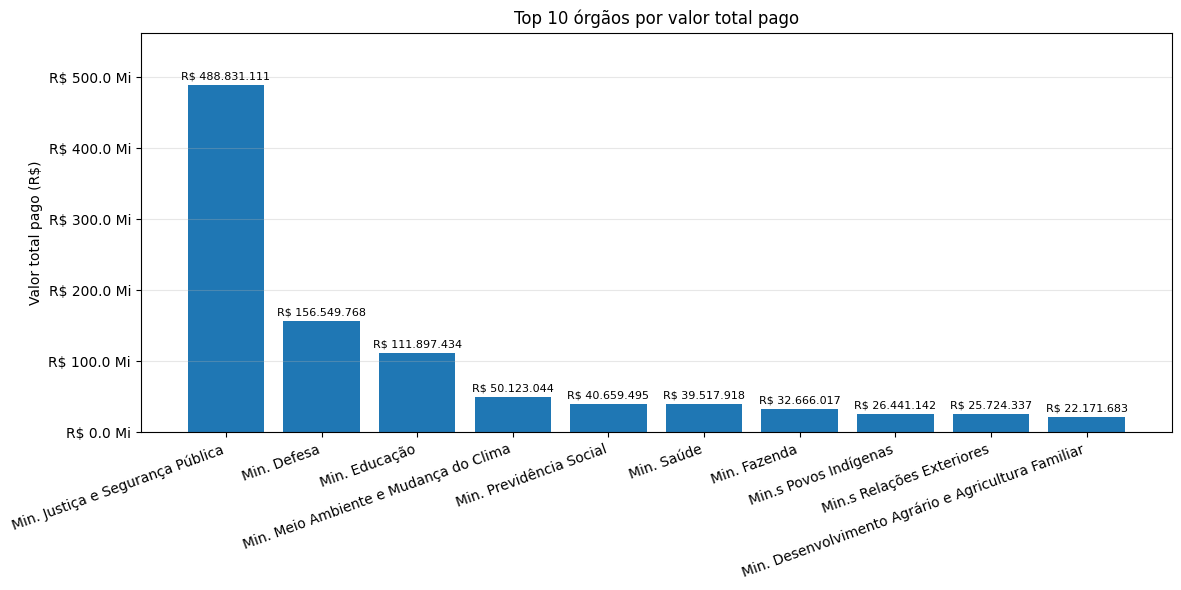

In [ ]:
q7_grafico = q7.head(10).copy()

q7_grafico['orgao'] = (
    q7_grafico['orgao']
        .str.replace('Ministério da', 'Min.', regex=False)
        .str.replace('Ministério do', 'Min.', regex=False)
        .str.replace('Ministério de', 'Min.', regex=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    q7_grafico['orgao'],
    q7_grafico['valor_total_pago']
)

plt.ylim(0, q7_grafico['valor_total_pago'].max() * 1.15)

for i, valor in enumerate(q7_grafico['valor_total_pago']):
    plt.text(
        i,
        valor + q7_grafico['valor_total_pago'].max() * 0.01,
        f'R$ {valor:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.title('Top 10 órgãos por valor total pago')
plt.xlabel('')
plt.ylabel('Valor total pago (R$)')

plt.xticks(rotation=20, ha='right')

plt.grid(axis='y', alpha=0.3)
from matplotlib.ticker import FuncFormatter

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f'R$ {x/1_000_000:.1f} Mi')
)
plt.tight_layout()
plt.show()

### Análise dos resultados

A análise identificou que o órgão posicionado no topo do ranking concentrou o maior valor total pago em viagens a serviço durante o período analisado.

Os demais órgãos apresentaram valores inferiores, evidenciando diferenças na execução das despesas relacionadas às viagens. A utilização da camada Gold permitiu responder à pergunta de negócio por meio de indicadores previamente agregados, simplificando a consulta e demonstrando a aplicação da arquitetura Medallion na disponibilização de dados para análise.